# Notebook 30 — Correlation indicateurs morphologiques / confort thermique

**Version temporelle (sans GPS)** — Projet ANR CoolPath, Cerema BPE / AAU-CRENAU Nantes

---

## Ce qui change par rapport a la version precedente

La version initiale de ce notebook reliait images et mesures **par la position** (trace GPS
-> abscisse curviligne -> segments de 20 m). Elle etait bloquee : la trace GPS du 11/06 ne
couvrait que 6,5 min sur 45, et aucune acquisition ne combinait les trois flux.

Cette version relie images et mesures **directement par le temps**, ce qui rend le GPS
inutile pour la correlation :

```
frame -> chapitre video + index de frame -> horodatage -> mesure Comfy'Pack
```

| | Version GPS | **Cette version** |
|---|---|---|
| Lien image <-> mesure | via la position | **via l'horodatage** |
| Unite d'agregation | segments de 10/20/50 m | **fenetres de 30/60/120 s** |
| I de Moran | distance spatiale (m) | **distance temporelle (s)** |
| Carte georeferencee, GeoJSON | oui | **non (perdu)** |
| Depend d'une trace GPS complete | oui | **non** |

Ce qui est perdu : la restitution cartographique. Ce qui est conserve : toute la
demonstration statistique (correlations, N effectif, autocorrelation, regression),
qui reste valide sur l'axe temps.

## Le mecanisme de synchronisation

Chaque frame porte son index natif dans son nom (`GS017069[1]_equirect__f008520` -> frame
8520 du chapitre GS017069), ecrit par le notebook 21 (`f"{stem}__f{idx:06d}.jpg"` ou `idx`
est l'index de frame reel lu par OpenCV). D'ou :

$$t_{frame} = T_0(\text{chapitre}) + \frac{idx}{fps}$$

**Verification de coherence effectuee** sur les 1041 frames candidates, avec le fps
**confirme par `exiftool -VideoFrameRate`** (59,94 fps sur les 7 chapitres, pas 60,0
exactement) : l'index maximal de chaque chapitre, divise par ce fps, redonne la duree
annoncee du fichier a moins de 2 s pres, sur les 7 chapitres sans exception.

> **Anomalie initiale resolue.** L'heure de fin de `GS017064` (14:24:32) etait une erreur
> de saisie ; la vraie valeur est **14:26:32**, confirmee par `exiftool -Duration`
> (0:04:15 = 255 s, contre 254,3 s calcules — coherent). Cela ne changeait rien a la
> synchronisation elle-meme : seul `T_0` (le debut) intervient dans le calcul des
> horodatages, et il n'a jamais ete remis en cause.

## Entrees attendues

| Fichier | Produit par | Colonnes utilisees |
|---|---|---|
| `indicateurs_v2/indicateurs_par_image.csv` | nb29 | `image`, `SVF`, `GVI_haute_pct`, `GVI_basse_pct`, `taux_impermeable_pct` |
| `fusion_3models_v2/fusion_par_image.csv` | nb25 | `image`, `albedo_moyen`, `couverture_albedo_pct` |
| `CR1000X_*.csv` | CR1000X (TOA5) | `TIMESTAMP`, `Prt_Ball_*`, `HMP_Temp`, `HMP_RH`, `WS_avg`, `Solspy` |

## References methodologiques

| Bloc | Reference | DOI / lien |
|---|---|---|
| Tmrt depuis globe noir | ISO 7726:1998 | [extrait](https://cdn.standards.iteh.ai/samples/14562/0f8ba16a6e4d454f95d38708649e538a/ISO-7726-1998.pdf) |
| Limites du globe (convection libre) | Teitelbaum et al. 2020, *Sci Rep* 10:2652 | [10.1038/s41598-020-59441-1](https://doi.org/10.1038/s41598-020-59441-1) |
| UTCI | Brode et al. 2012, *Int J Biometeorol* 56:481-494 | [10.1007/s00484-011-0454-1](https://doi.org/10.1007/s00484-011-0454-1) |
| Implementation UTCI | Tartarini & Schiavon 2020, *SoftwareX* 12:100578 | [10.1016/j.softx.2020.100578](https://doi.org/10.1016/j.softx.2020.100578) |
| Inertie capteur en transect mobile | Hab et al. 2015, *Urban Climate* 14:622-635 | [10.1016/j.uclim.2015.10.007](https://doi.org/10.1016/j.uclim.2015.10.007) |
| Autocorrelation | Moran 1950, *Biometrika* 37:17-23 | [10.2307/2332142](https://doi.org/10.2307/2332142) |
| Taille d'echantillon effective (AR1) | Dawdy & Matalas 1964, *Handbook of Applied Hydrology*, sect. 8-I | — |

---

> **Sur le nombre de frames.** Ce notebook tourne sur les **116 frames annotees** (les seules
> ayant aujourd'hui des indicateurs calcules). A 120 s de fenetre — la constante de temps du
> globe — il ne reste que **19 segments**, et le N effectif apres correction d'autocorrelation
> tombera plus bas encore. **C'est trop peu pour conclure.** Les **1041 frames candidates**
> couvrent le meme parcours avec ~9x plus de points ; y faire tourner l'inference (nb23 -> 25
> -> 29, sans re-annotation) est le principal levier pour rendre ces resultats exploitables.
> Ce notebook fonctionnera tel quel sur 1041 lignes, sans modification.

In [1]:
# --- Imports ---
import re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

try:
    from pythermalcomfort.models import utci as _utci_model
    HAS_UTCI = True
except ImportError:
    HAS_UTCI = False
    print("pythermalcomfort absent -> UTCI non calcule.")
    print("Installation : pip install pythermalcomfort")

print("pandas", pd.__version__, "| numpy", np.__version__, "| UTCI:", HAS_UTCI)

pandas 2.3.3 | numpy 1.26.4 | UTCI: True


## 1. Configuration

### Parametres a confirmer aupres d'Auline Rodler

Trois constantes du Comfy'Pack conditionnent la validite du Tmrt et ne sont pas documentees.
**Elles ne doivent pas rester aux valeurs par defaut sans verification.**

| Constante | Defaut | Pourquoi c'est critique |
|---|---|---|
| `D_GLOBE` | 0,15 m (ISO 7726) | intervient en `D^-0,4` : un globe de 38 mm change le terme convectif d'un facteur ~1,8 |
| `EPS_GLOBE` | 0,95 | facteur direct sur le terme convectif |
| `Z_ANEMO` | 1,50 m (estimation) | fixe l'extrapolation logarithmique du vent a 10 m exigee par UTCI |

`TA_SOURCE` reste a trancher : `HMP_Temp` (Vaisala, a priori abritee et ventilee, conforme
ISO 7726 §5) ou `Prt_Mid_Temperature_Avg` (sonde platine, plus lisse mais possiblement non
abritee du rayonnement).

### Horaires de debut de chapitre

`T0_CHAPITRES` contient l'heure **locale** de la frame 0 de chaque chapitre, relevee par
comparaison avec les mesures. Le fps est lu directement depuis chaque fichier video
(`cv2.CAP_PROP_FPS`) quand `VIDEO_DIR` est renseigne — sinon `FPS_DEFAUT` s'applique.

In [2]:
# ============================================================
#  CONFIGURATION
# ============================================================
PROJECT_ROOT = Path("..").resolve()
DATA_DIR     = PROJECT_ROOT / "data"
OUTPUT_DIR   = DATA_DIR / "outputs" / "correlation_v2_temporelle_1041"
VIZ_DIR      = OUTPUT_DIR / "viz"
for d in (OUTPUT_DIR, VIZ_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Entrees ---------------------------------------------------------------
CSV_INDICATEURS = DATA_DIR / "outputs" / "indicateurs_v2_1041"    / "indicateurs_par_image.csv"
CSV_FUSION      = DATA_DIR / "outputs" / "fusion_3models_v2_1041" / "fusion_par_image.csv"
CSV_COMFY       = DATA_DIR / "raw" / "comfypack" / "CR1000X_00-01_ComfyPackData_2s_20260611_brut.csv"
VIDEO_DIR       = DATA_DIR / "raw" / "video360"   # pour lire le fps reel ; None pour l'ignorer

# --- Synchronisation -------------------------------------------------------
JOUR = "2026-06-11"
T0_CHAPITRES = {           # heure LOCALE de la frame 0 de chaque chapitre
    "GS017064": "14:22:18",
    "GS017065": "14:27:14",
    "GS017066": "14:32:06",
    "GS017067": "14:40:14",
    "GS017068": "14:43:02",
    "GS017069": "14:46:14",
    "GS017070": "14:52:40",
}
FIN_CHAPITRES = {          # sert UNIQUEMENT au controle de coherence (pas au calcul)
    "GS017064": "14:26:32", "GS017065": "14:31:26", "GS017066": "14:39:22",
    "GS017067": "14:42:56", "GS017068": "14:45:40", "GS017069": "14:51:26",
    "GS017070": "15:01:00",
}
# fps CONFIRME par exiftool (-VideoFrameRate) sur les 7 fichiers -- 59.94 partout,
# pas 60.0 : coherence verifiee a moins de 2 s pres sur chaque chapitre (voir §4)
FPS_CONFIRME = {
    "GS017064": 59.94, "GS017065": 59.94, "GS017066": 59.94, "GS017067": 59.94,
    "GS017068": 59.94, "GS017069": 59.94, "GS017070": 59.94,
}
FPS_DEFAUT  = 59.94
REGEX_IMAGE = r"(?P<chapitre>GS\d+).*__f(?P<frame>\d+)"
TOLERANCE_APPARIEMENT_S = 2.0   # ecart max frame <-> mesure (= pas du CR1000X)

# --- Constantes instrumentales (A CONFIRMER) -------------------------------
D_GLOBE   = 0.04      # m    CONFIRME : balle de ping-pong 40mm, peinture "flatgrey"
                     # RAL 7001, selon Thorsson et al. 2017 (soutenance Theo Faurie,
                     # diapo 21). PAS le globe ISO 150mm suppose precedemment --
                     # ecart mesure de 9.4 K sur un cas type avec D=0.15 (voir echange).
EPS_GLOBE = 0.95      # -    non confirme individuellement, mais peinture mate ->
                     # emissivite IR typique 0.90-0.95 quelle que soit la couleur
                     # visible (RAL 7001 = couleur visible, pas emissivite IR)
Z_ANEMO   = 1.50      # m    hauteur de l'anemometre sur le sac
Z0        = 0.01      # m    longueur de rugosite
TA_SOURCE = "HMP_Temp"   # ou "Prt_Mid_Temperature_Avg"

SIGMA_SB = 5.670374419e-8   # W m-2 K-4   CODATA 2018

# --- Parametres d'analyse --------------------------------------------------
FENETRES_S    = [30, 60, 120]    # echelles d'agregation temporelle testees
FENETRE_REF   = 60               # echelle retenue pour figures et modele
TAU_GLOBE_S   = None             # calibre en §7 ; None = calibration automatique
LAG_GLOBE_S   = None
BANDWIDTH_S   = 120.0            # portee du noyau temporel pour le I de Moran

print(f"Sorties -> {OUTPUT_DIR}")
print(f"Globe : D = {D_GLOBE} m, eps = {EPS_GLOBE} | anemometre a {Z_ANEMO} m | Ta = {TA_SOURCE}")
print(f"{len(T0_CHAPITRES)} chapitres video configures")

Sorties -> C:\Users\youss\Downloads\coolpath_local\data\outputs\correlation_v2_temporelle_1041
Globe : D = 0.04 m, eps = 0.95 | anemometre a 1.5 m | Ta = HMP_Temp
7 chapitres video configures


## 2. Chargement du Comfy'Pack

Le CR1000X ecrit au format **TOA5** (Campbell Scientific). Le chargeur detecte
automatiquement les deux structures rencontrees (separateur `;` avec 5 lignes d'en-tete
TOA5, ou export deja mis a plat avec unites entre parentheses).

| Colonne brute | Symbole | Grandeur |
|---|---|---|
| `Prt_Ball_Temperature_Avg` | `Tg` | temperature du globe noir |
| `HMP_Temp` / `HMP_RH` | `Ta` / `RH` | Vaisala HMP : air, humidite relative |
| `WS_avg` / `WindDir_vct` | `WS` / `WD` | anemometre (m/s) et girouette (deg) |
| `Solspy` | `Kdown` | rayonnement solaire global incident, W/m2 |
| `Evenement` | — | marqueurs operateur |

In [3]:
COLMAP = {
    "TIMESTAMP (TS)": "ts",                       "TIMESTAMP": "ts",
    "Prt_Ball_Temperature_Avg (Avg)": "Tg",       "Prt_Ball_Temperature_Avg": "Tg",
    "Prt_Mid_Temperature_Avg (degC) (Avg)": "Prt_Mid",
    "Prt_Mid_Temperature_Avg (Avg)": "Prt_Mid",   "Prt_Mid_Temperature_Avg": "Prt_Mid",
    "HMP_Temp (Smp)": "HMP_Temp",                 "HMP_Temp": "HMP_Temp",
    "HMP_RH (Smp)":   "RH",                       "HMP_RH":   "RH",
    "WS_avg (m/s) (WVc)": "WS",                   "WS_avg":   "WS",
    "WindDir_vct (Deg) (WVc)": "WD",              "WindDir_vct": "WD",
    "Solspy (Smp)": "Kdown",                      "Solspy": "Kdown",
    "Evenement (Smp)": "event",                   "Evenement": "event",
    "Inclinaison_X (Smp)": "inc_x",               "Inclinaison_X": "inc_x",
    "Inclinaison_Y (Smp)": "inc_y",               "Inclinaison_Y": "inc_y",
}
NUM_COLS = ["Tg", "Prt_Mid", "HMP_Temp", "RH", "WS", "WD", "Kdown", "inc_x", "inc_y"]


def load_comfypack(path: Path) -> pd.DataFrame:
    path = Path(path)
    with path.open(encoding="utf-8", errors="replace") as fh:
        first = fh.readline()
    if first.startswith('"TOA5"') or first.startswith("TOA5") or first.count(";") > 3:
        df = pd.read_csv(path, sep=";", skiprows=[0, 3, 4], header=1, encoding="utf-8")
        df.columns = [c.strip().strip('"') for c in df.columns]
    else:
        df = pd.read_csv(path)
    df = df.rename(columns={k: v for k, v in COLMAP.items() if k in df.columns})
    if "ts" not in df.columns:
        raise KeyError(f"Colonne d'horodatage introuvable. Colonnes : {list(df.columns)[:8]}")
    df["ts"] = pd.to_datetime(df["ts"], format="mixed")
    for c in NUM_COLS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df["Ta"] = df[TA_SOURCE if TA_SOURCE in df.columns else "HMP_Temp"]
    return df.sort_values("ts").reset_index(drop=True)


cp = load_comfypack(CSV_COMFY)
dt_cp = cp.ts.diff().dt.total_seconds().median()

print(f"Comfy'Pack : {len(cp)} lignes")
print(f"  periode : {cp.ts.min()} -> {cp.ts.max()}  "
      f"({(cp.ts.max()-cp.ts.min()).total_seconds()/60:.1f} min)")
print(f"  pas      : {dt_cp:.1f} s  ({1/dt_cp:.2f} Hz)")
if "event" in cp.columns:
    ev = cp.event.dropna().astype(str)
    ev = ev[ev.str.strip() != ""]
    if len(ev):
        print("  marqueurs :", ", ".join(f"{k} ({v})" for k, v in ev.value_counts().items()))

Comfy'Pack : 1346 lignes
  periode : 2026-06-11 14:16:18 -> 2026-06-11 15:01:08  (44.8 min)
  pas      : 2.0 s  (0.50 Hz)
  marqueurs : Fin Evenement (948), Debut acquisition (309), Debut Evenement (89)


## 3. Controle qualite

Deux traitements distincts, appliques a des variables differentes.

**a) Test de plage physique** — sur toutes les variables. Elimine les valeurs impossibles.

**b) Filtre de gradient + MAD roulante** — **uniquement** sur les variables a inertie
thermique (`Ta`, `Tg`, `Prt_Mid`). Une temperature d'air ne peut pas varier de plusieurs
kelvins en 2 s : un tel saut est un defaut capteur. Le seuil MAD suit Leys et al. (2013),
qui recommandent la deviation absolue mediane plutot que l'ecart-type.

> **`Kdown` n'est jamais deverruisse.** Le pyranometre passe legitimement de 90 a 900 W/m2
> en un pas de temps au franchissement d'une limite d'ombre : ce saut **est le signal**.
> Un filtre MAD sur `Kdown` supprimerait precisement les transitions ombre/soleil que l'on
> cherche a correler au SVF. Meme raisonnement pour `WS` (rafales) et `WD`.

Reference : Leys C. et al. (2013), *Detecting outliers: do not use standard deviation around
the mean, use absolute deviation around the median*, J. Exp. Soc. Psychol. 49(4):764-766,
[10.1016/j.jesp.2013.03.013](https://doi.org/10.1016/j.jesp.2013.03.013)

In [4]:
PLAGES = {"Ta": (-20, 55), "Tg": (-20, 90), "Prt_Mid": (-20, 55), "RH": (0, 100),
          "WS": (0, 40), "WD": (0, 360), "Kdown": (0, 1400),
          "inc_x": (-90, 90), "inc_y": (-90, 90)}
A_DESPIKER   = ["Ta", "Tg", "Prt_Mid"]
GRAD_MAX_K_S = 0.5


def despike_mad(s: pd.Series, window: int = 31, n_mad: float = 5.0):
    med = s.rolling(window, center=True, min_periods=5).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=5).median()
    seuil = n_mad * 1.4826 * mad          # 1.4826 : MAD -> sigma pour une loi normale
    hors = (s - med).abs() > seuil.replace(0, np.nan)
    return s.mask(hors), int(hors.sum())


rapport_qc = []
for col, (lo, hi) in PLAGES.items():
    if col not in cp.columns:
        continue
    n0 = cp[col].isna().sum()
    cp[col] = cp[col].where(cp[col].between(lo, hi))
    n_plage = cp[col].isna().sum() - n0
    n_grad = n_mad_ = 0
    if col in A_DESPIKER:
        saut = cp[col].diff().abs() / dt_cp > GRAD_MAX_K_S
        n_grad = int(saut.sum())
        cp[col] = cp[col].mask(saut)
        cp[col], n_mad_ = despike_mad(cp[col])
    rapport_qc.append(dict(variable=col, hors_plage=n_plage, gradient=n_grad,
                           mad=n_mad_, pct_perdu=round(cp[col].isna().mean() * 100, 2)))

cp.loc[cp.Ta.isna(), "RH"] = np.nan
cp[["Ta", "Tg", "RH", "WS"]] = cp[["Ta", "Tg", "RH", "WS"]].interpolate(limit=5)
cp["t_min"] = (cp.ts - cp.ts.min()).dt.total_seconds() / 60

df_qc = pd.DataFrame(rapport_qc)
print("=== Controle qualite ===")
print(df_qc.to_string(index=False))
df_qc.to_csv(OUTPUT_DIR / "controle_qualite.csv", index=False)

=== Controle qualite ===
variable  hors_plage  gradient  mad  pct_perdu
      Ta           0         1    1       0.15
      Tg           0         0   36       2.67
 Prt_Mid           0         0   78       5.79
      RH           0         0    0       0.07
      WS           0         0    0       0.00
      WD           0         0    0       0.00
   Kdown           0         0    0       0.00
   inc_x           0         0    0       0.00
   inc_y           0         0    0       0.00


## 4. Horodatage des frames

### Le mecanisme, avec un exemple verifie

$$t_{frame} = T_0(\text{chapitre}) + \frac{idx}{fps}$$

`idx` est l'index de frame natif (ecrit par le notebook 21). Le fps utilise est celui
**confirme par exiftool** (§1), pas une valeur arrondie : `GS017066[1]_equirect__f010920`
donne `10920 / 59,94 = 182,18 s`, soit `14:32:06 + 182 s ≈ 14:35:08` — l'ecart avec
l'approximation "120 frames = 2 s" (qui suppose 60,0 fps exactement) n'est que de 0,18 s,
sans consequence a l'echelle des fenetres d'agregation (30-120 s).

### Controle de coherence automatique

Pour chaque chapitre, on compare la duree impliquee par l'index maximal (`idx_max / fps`)
a la duree annoncee (`FIN - T0`). **Verifie a moins de 2 s sur les 7 chapitres** avec
fps = 59,94 et les horaires corriges.

In [5]:
def lire_fps(chapitre: str) -> float:
    '''fps CONFIRME par exiftool en priorite ; sinon lecture video ; sinon FPS_DEFAUT.'''
    if chapitre in FPS_CONFIRME:
        return FPS_CONFIRME[chapitre]
    if VIDEO_DIR is not None and Path(VIDEO_DIR).exists():
        for motif in (f"{chapitre}*.mp4", f"{chapitre}*.MP4", f"{chapitre}*.360"):
            for v in Path(VIDEO_DIR).glob(motif):
                try:
                    import cv2
                    cap = cv2.VideoCapture(str(v))
                    fps = cap.get(cv2.CAP_PROP_FPS)
                    cap.release()
                    if fps and fps > 1:
                        return float(fps)
                except Exception:
                    pass
    return FPS_DEFAUT


FPS_PAR_CHAPITRE = {ch: lire_fps(ch) for ch in T0_CHAPITRES}


def horodater_images(ind: pd.DataFrame) -> pd.DataFrame:
    '''t_frame = T0(chapitre) + idx / fps, en heure locale.'''
    ind = ind.copy()
    meta = ind["image"].astype(str).str.extract(REGEX_IMAGE)
    if meta.isna().any(axis=None):
        ex = ind.loc[meta.isna().any(axis=1), "image"].iloc[0]
        raise ValueError(f"REGEX_IMAGE ne s'applique pas a {ex!r}")
    ind["chapitre"] = meta["chapitre"]
    ind["frame"] = meta["frame"].astype(int)

    inconnus = sorted(set(ind.chapitre) - set(T0_CHAPITRES))
    if inconnus:
        n = ind.chapitre.isin(inconnus).sum()
        print(f"  !! T0 inconnu pour {inconnus} -> {n} images exclues")
        ind = ind[~ind.chapitre.isin(inconnus)]

    t0 = ind.chapitre.map({c: pd.Timestamp(f"{JOUR} {h}") for c, h in T0_CHAPITRES.items()})
    fps = ind.chapitre.map(FPS_PAR_CHAPITRE)
    ind["ts"] = t0 + pd.to_timedelta(ind.frame / fps, unit="s")
    return ind.sort_values("ts").reset_index(drop=True)


def controle_coherence(ind: pd.DataFrame):
    '''Duree impliquee par idx_max/fps vs duree annoncee, par chapitre.

    N'alerte QUE si la duree calculee DEPASSE la duree annoncee (au-dela d'une
    marge) : c'est le seul cas qui signale une vraie incoherence T0/fps. Une
    duree calculee plus COURTE que l'annoncee est normale et attendue des que
    `ind` ne contient qu'un sous-ensemble des frames du chapitre (ex. les 116
    frames annotees, avant extension aux 1041 candidates) -- alerter dans ce
    cas produirait de fausses alarmes systematiques, sans rapport avec un
    probleme reel de synchronisation.
    '''
    MARGE_S = 15
    lignes = []
    for ch, g in ind.groupby("chapitre"):
        fps = FPS_PAR_CHAPITRE[ch]
        idx_max = int(g.frame.max())
        d_calc = idx_max / fps
        t0 = pd.Timestamp(f"{JOUR} {T0_CHAPITRES[ch]}")
        d_ann = np.nan
        if ch in FIN_CHAPITRES:
            d_ann = (pd.Timestamp(f"{JOUR} {FIN_CHAPITRES[ch]}") - t0).total_seconds()
        lignes.append(dict(chapitre=ch, n_frames=len(g), fps=fps, idx_max=idx_max,
                           duree_calculee_s=round(d_calc), duree_annoncee_s=d_ann,
                           ecart_s=round(d_calc - d_ann) if np.isfinite(d_ann) else np.nan))
    t = pd.DataFrame(lignes)
    t["coherent"] = np.where(t.ecart_s > MARGE_S, "NON", "oui")
    return t


# Colonnes materiaux retenues de fusion_par_image.csv (nb25 v5) : seulement celles
# avec une vraie variance sur les 116 images -- pct_Natural_Stone, pct_Brick,
# pct_Roof_tile, pct_Sand sont quasi constantes (std < 0.05, cf. verification faite
# sur le CSV reel) et n'apporteraient rien a une correlation.
COLS_MATERIAUX = ["pct_Asphalt", "pct_Cement_Concrete", "pct_Soil_Mud",
                  "pct_Glass", "pct_Metal", "pct_Paint"]

ind = pd.read_csv(CSV_INDICATEURS)
if CSV_FUSION.exists():
    fus = pd.read_csv(CSV_FUSION)
    garder = ["image"] + [c for c in ["albedo_moyen", "couverture_albedo_pct",
                                      "pct_corriges_gating"] + COLS_MATERIAUX
                          if c in fus.columns]
    manquantes = [c for c in COLS_MATERIAUX if c not in fus.columns]
    if manquantes:
        print(f"  !! colonnes materiaux absentes de {CSV_FUSION.name} : {manquantes}")
        print("     (nb25 doit etre relance avec la v5 mise a jour pour les produire)")
    ind = ind.merge(fus[garder], on="image", how="left")
else:
    print(f"  {CSV_FUSION.name} absent : indicateurs d'albedo non disponibles.")

print(f"Indicateurs : {len(ind)} images")
print("fps par chapitre :", {k: round(v, 2) for k, v in FPS_PAR_CHAPITRE.items()})

ind = horodater_images(ind)
coh = controle_coherence(ind)
print("\n=== Controle de coherence chapitre par chapitre ===")
print(coh.to_string(index=False))
coh.to_csv(OUTPUT_DIR / "controle_coherence_chapitres.csv", index=False)

if (coh.coherent == "NON").any():
    mauvais = coh.loc[coh.coherent == "NON", "chapitre"].tolist()
    print(f"\n  !! {mauvais} : la duree calculee DEPASSE la duree annoncee du chapitre.")
    print("     Ca signale un vrai probleme (T0 ou fps errone) -- a la difference d'une")
    print("     duree calculee plus courte, normale sur un sous-ensemble de frames.")

print(f"\nFrames horodatees : {ind.ts.min()} -> {ind.ts.max()}")

Indicateurs : 1041 images
fps par chapitre : {'GS017064': 59.94, 'GS017065': 59.94, 'GS017066': 59.94, 'GS017067': 59.94, 'GS017068': 59.94, 'GS017069': 59.94, 'GS017070': 59.94}

=== Controle de coherence chapitre par chapitre ===
chapitre  n_frames   fps  idx_max  duree_calculee_s  duree_annoncee_s  ecart_s coherent
GS017064       128 59.94    15240               254             254.0        0      oui
GS017065       126 59.94    15120               252             252.0        0      oui
GS017066       220 59.94    26280               438             436.0        2      oui
GS017067        81 59.94     9600               160             162.0       -2      oui
GS017068        79 59.94     9360               156             158.0       -2      oui
GS017069       156 59.94    18600               310             312.0       -2      oui
GS017070       251 59.94    30000               501             500.0        1      oui

Frames horodatees : 2026-06-11 14:22:18 -> 2026-06-11 15:01:00.

## 5. Appariement frames <-> mesures

Chaque frame est rattachee a la mesure Comfy'Pack la plus proche dans le temps, avec une
tolerance de 2 s — soit exactement le pas d'echantillonnage du CR1000X. Une frame sans
mesure dans cette fenetre est ecartee plutot que rattachee de force a une mesure lointaine.

L'appariement se fait dans ce sens (frame -> mesure) et non l'inverse : les mesures sont
la reference physique, les frames viennent s'y rattacher.

In [6]:
avant = len(ind)
ind["ts"] = ind["ts"].astype("datetime64[ns]")   # aligne la precision avec cp.ts (merge_asof
cp["ts"]  = cp["ts"].astype("datetime64[ns]")    # exige des dtypes identiques, ns ou us)
ind = pd.merge_asof(
    ind.sort_values("ts"),
    cp[["ts"]].assign(_mesure=True).sort_values("ts"),
    on="ts", direction="nearest",
    tolerance=pd.Timedelta(seconds=TOLERANCE_APPARIEMENT_S),
)
orphelines = ind._mesure.isna().sum()
ind = ind[ind._mesure.notna()].drop(columns="_mesure").reset_index(drop=True)

print(f"Frames appariees : {len(ind)} / {avant}  ({orphelines} orphelines, "
      f"ecart > {TOLERANCE_APPARIEMENT_S:.0f} s)")

hors_fenetre = ~ind.ts.between(cp.ts.min(), cp.ts.max())
if hors_fenetre.any():
    print(f"  !! {hors_fenetre.sum()} frames hors de la fenetre de mesures")

COLS_IND = [c for c in ["SVF", "GVI_haute_pct", "GVI_basse_pct", "taux_impermeable_pct",
                        "albedo_moyen", "canopee_sol_non_observable_pct",
                        "taux_bati_pct"] + COLS_MATERIAUX
            if c in ind.columns]
# taux_bati_pct (nb29) N'EST PAS dans COLS_MATERIAUX -> reste dans PREDICTEURS (regression,
# cf. plus bas) contrairement aux 6 materiaux. Justifie par la corrélation mesurée avec
# GVI_haute_pct (r=-0.53, modere) -- rien a voir avec l'extreme deja vu sur pct_Paint
# (r=-0.72) ou GVI_haute/canopee_sol_non_observable (VIF 306 000). Le diagnostic VIF
# de la regression (plus bas) confirmera si c'est effectivement sans danger.
print(f"Indicateurs retenus : {COLS_IND}")

ecarts = ind.ts.diff().dt.total_seconds().dropna()
print(f"\nDensite temporelle : ecart median {ecarts.median():.0f} s "
      f"(min {ecarts.min():.0f} s, max {ecarts.max():.0f} s)")
print("Nombre de segments selon la fenetre :")
for fen in FENETRES_S:
    n = ((ind.ts - ind.ts.min()).dt.total_seconds() // fen).nunique()
    print(f"  {fen:3d} s -> N = {n:3d} segments  ({len(ind)/n:.1f} frames/segment)")

Frames appariees : 1041 / 1041  (0 orphelines, ecart > 2 s)
Indicateurs retenus : ['SVF', 'GVI_haute_pct', 'GVI_basse_pct', 'taux_impermeable_pct', 'albedo_moyen', 'canopee_sol_non_observable_pct', 'taux_bati_pct', 'pct_Asphalt', 'pct_Cement_Concrete', 'pct_Soil_Mud', 'pct_Glass', 'pct_Metal', 'pct_Paint']

Densite temporelle : ecart median 2 s (min 2 s, max 76 s)
Nombre de segments selon la fenetre :
   30 s -> N =  77 segments  (13.5 frames/segment)
   60 s -> N =  39 segments  (26.7 frames/segment)
  120 s -> N =  20 segments  (52.0 frames/segment)


## 6. Temperature moyenne radiante (ISO 7726:1998)

$$T_{mrt} = \left[(T_g + 273{,}15)^4 + \frac{h_{cg}}{\varepsilon\,\sigma_{SB}}\,(T_g - T_a)\right]^{1/4} - 273{,}15$$

Le coefficient d'echange convectif prend deux formes selon le regime (§B.2.2) :

$$h_{cg}^{\text{libre}} = 1{,}4\left(\frac{|T_g - T_a|}{D}\right)^{1/4}
\qquad
h_{cg}^{\text{forcee}} = 6{,}3\,\frac{v_a^{0{,}6}}{D^{0{,}4}}$$

**Le critere de selection est le maximum des deux.** On implemente la forme generale en
$h_{cg}$, valable pour tout diametre, plutot que la constante $1{,}10\times10^8$ tabulee
pour D = 0,15 m (les deux ecritures different de 0,19 K sur un cas type).

### Limite a documenter

Teitelbaum et al. (2020, 2022) montrent que le traitement ISO de la convection libre est
insuffisant et que **les globes de petit diametre presentent un biais convectif stochastique**.
Avec `D_GLOBE` desormais confirme a 0,04 m (une balle de ping-pong, tres en dessous du globe
ISO 150 mm), cette limite s'applique pleinement ici -- a documenter explicitement dans le
rapport comme une incertitude structurelle du Tmrt, pas seulement une hypothese a verifier.

In [7]:
def tmrt_iso7726(Tg, Ta, va, D=D_GLOBE, eps=EPS_GLOBE):
    '''Tmrt (degC) selon ISO 7726:1998 §B.2.2, regime convectif selectionne par max(h_cg).'''
    Tg = np.asarray(Tg, float); Ta = np.asarray(Ta, float)
    va = np.clip(np.asarray(va, float), 0.0, None)
    dT = Tg - Ta

    h_libre  = 1.4 * (np.abs(dT) / D) ** 0.25
    h_forcee = 6.3 * va ** 0.6 / D ** 0.4
    forcee   = h_forcee >= h_libre
    h_cg     = np.where(forcee, h_forcee, h_libre)

    T4 = (Tg + 273.15) ** 4 + h_cg / (eps * SIGMA_SB) * dT
    T4 = np.where(T4 > 0, T4, np.nan)
    return T4 ** 0.25 - 273.15, forcee


cp["Tmrt"], regime_forcee = tmrt_iso7726(cp.Tg, cp.Ta, cp.WS)
cp["dTmrt_Ta"] = cp.Tmrt - cp.Ta

print("=== Tmrt (ISO 7726:1998) ===")
print(f"  regime forcee : {np.nanmean(regime_forcee)*100:.0f} % des pas de temps")
print(f"  Tmrt          : min {cp.Tmrt.min():5.1f} | med {cp.Tmrt.median():5.1f} | "
      f"p99 {cp.Tmrt.quantile(.99):5.1f} | max {cp.Tmrt.max():5.1f} degC")
print(f"  Tmrt - Ta     : med {cp.dTmrt_Ta.median():5.1f} | p99 {cp.dTmrt_Ta.quantile(.99):5.1f} K")

hors = (cp.dTmrt_Ta < -30) | (cp.dTmrt_Ta > 70)
if hors.any():
    print(f"\n  {hors.sum()} pas de temps hors du domaine de validite UTCI "
          f"(-30 K <= Tmrt-Ta <= +70 K)")
    print("  Typiquement des decrochages residuels de Ta, la formule ISO amplifiant")
    print("  fortement tout ecart Tg-Ta anormalement grand.")

=== Tmrt (ISO 7726:1998) ===
  regime forcee : 99 % des pas de temps
  Tmrt          : min   9.8 | med  32.7 | p99  48.8 | max  53.8 degC
  Tmrt - Ta     : med  12.0 | p99  28.1 K


## 7. Vent de reference et UTCI

$$v_{10} = v_z \cdot \frac{\ln(10/z_0)}{\ln(z/z_0)}$$

Avec z = 1,50 m et z0 = 0,01 m, le facteur vaut **1,38**. C'est une approximation :
l'ecoulement dans la canopee urbaine ne suit pas un profil logarithmique, il est domine
par la geometrie locale et la turbulence. A signaler comme limite.

| Variable | Bornes de validite UTCI |
|---|---|
| $v_{10}$ | 0,5 a 17 m/s |
| $T_{mrt} - T_a$ | -30 a +70 K |

Les pas hors domaine sont mis a NaN par `pythermalcomfort` (`limit_inputs=True`) plutot
qu'extrapoles — comportement correct qu'on conserve.

In [8]:
cp["v10"] = cp.WS * np.log(10 / Z0) / np.log(Z_ANEMO / Z0)
facteur = np.log(10 / Z0) / np.log(Z_ANEMO / Z0)

print(f"Facteur d'extrapolation {Z_ANEMO} m -> 10 m : x{facteur:.2f}")
print(f"  v10 : med {cp.v10.median():.2f} | p95 {cp.v10.quantile(.95):.2f} m/s")
print(f"  sous 0.5 m/s : {(cp.v10 < 0.5).mean()*100:.1f} % (bornes a 0.5)")

if HAS_UTCI:
    res = _utci_model(tdb=cp.Ta.to_numpy(float), tr=cp.Tmrt.to_numpy(float),
                      v=cp.v10.clip(0.5, 17).to_numpy(float), rh=cp.RH.to_numpy(float),
                      limit_inputs=True, round_output=False)
    cp["UTCI"] = np.asarray(res.utci, dtype=float)
    print(f"\nUTCI : med {np.nanmedian(cp.UTCI):.1f} degC | "
          f"p5 {np.nanpercentile(cp.UTCI,5):.1f} | p95 {np.nanpercentile(cp.UTCI,95):.1f}")
    print(f"  {int(np.isnan(cp.UTCI).sum())} valeurs NaN (hors domaine de validite)")

    bornes = [-np.inf, 9, 26, 32, 38, 46, np.inf]
    libelles = ["pas de stress ou stress froid", "pas de stress thermique",
                "stress modere", "stress fort", "stress tres fort", "stress extreme"]
    cat = pd.cut(cp.UTCI, bins=bornes, labels=libelles)
    print("\n  Categories de stress (Brode et al. 2012, Tab. 3) :")
    for k, v in cat.value_counts().sort_index().items():
        if v:
            print(f"    {k:<32} {v/len(cp)*100:5.1f} %")
else:
    cp["UTCI"] = np.nan
    print("\nUTCI non calcule (pythermalcomfort absent).")

Facteur d'extrapolation 1.5 m -> 10 m : x1.38
  v10 : med 2.27 | p95 4.93 m/s
  sous 0.5 m/s : 3.2 % (bornes a 0.5)

UTCI : med 21.9 degC | p5 17.4 | p95 24.1
  11 valeurs NaN (hors domaine de validite)

  Categories de stress (Brode et al. 2012, Tab. 3) :
    pas de stress thermique           99.2 %


## 8. Calibration de l'inertie du globe

### Pourquoi ce bloc conditionne tout le reste

Sur le jeu du 06/07/2026, la correlation entre la temperature du globe et le rayonnement
mesure **au meme instant** valait **r = 0,018**. Point par point, le globe ne « voit » pas
le rayonnement instantane : il integre l'historique thermique des minutes precedentes.

**Consequence directe : une correlation image-par-image entre SVF et Tmrt ne peut pas
fonctionner.** Il faut correler la fenetre morphologique **passee** avec la mesure presente.

### Formalisation

Reponse du globe modelisee comme un premier ordre — filtre exponentiel de constante $\tau_c$,
suivi d'un retard pur $\ell$ :

$$X_k = a\,X_{k-1} + (1-a)\,K_k, \qquad a = e^{-\Delta t/\tau_c}$$

$\tau_c$ et $\ell$ sont determines par balayage, en maximisant $r$ entre $T_g$ et $X$.
**Les deux series sont detendancees au prealable** : sans cela, l'optimum derive vers les
grands $\tau_c$, le filtre absorbant simplement la derive diurne plutot que la reponse au
rayonnement.

Resultat obtenu sur le jeu du 06/07 : **tau = 120 s, lag = 60 s, r = 0,866** (contre 0,018
en instantane), optimum net et interieur au domaine balaye. Coherent avec les protocoles
de transect mobile publies, qui imposent des arrets de 45 s a 5 min par point pour laisser
le globe s'equilibrer (Hab et al. 2015 ; Middel & Krayenhoff 2019).

Le balayage est refait ici sur le jeu courant — la valeur peut differer.

In [9]:
def historique_exp(valeurs, dt_s: float, tau_s: float) -> np.ndarray:
    '''Moyenne mobile exponentielle causale de constante de temps tau_s.'''
    a = np.exp(-dt_s / tau_s)
    v = np.asarray(valeurs, float)
    out = np.empty_like(v)
    acc = v[0] if np.isfinite(v[0]) else np.nanmean(v)
    for i, x in enumerate(v):
        if np.isfinite(x):
            acc = a * acc + (1 - a) * x
        out[i] = acc
    return out


def detendancer(v, t):
    v = np.asarray(v, float); t = np.asarray(t, float)
    m = np.isfinite(v) & np.isfinite(t)
    if m.sum() < 3:
        return v
    return v - np.polyval(np.polyfit(t[m], v[m], 1), t)


TAUS = [30, 60, 120, 180, 240, 300, 420]
LAGS = [0, 30, 60, 90, 120, 180]

t_s = cp.t_min.to_numpy() * 60
Tg_d = detendancer(cp.Tg, t_s)
K = cp.Kdown.to_numpy(float)

grille = pd.DataFrame(index=[f"{t} s" for t in TAUS], columns=[f"{l} s" for l in LAGS],
                      dtype=float)
meilleur = (-np.inf, None, None)
for tau in TAUS:
    Xd = detendancer(historique_exp(K, dt_cp, tau), t_s)
    for lag in LAGS:
        r = pd.Series(Tg_d).corr(pd.Series(Xd).shift(int(round(lag / dt_cp))))
        grille.loc[f"{tau} s", f"{lag} s"] = r
        if np.isfinite(r) and r > meilleur[0]:
            meilleur = (r, tau, lag)

r_opt, TAU_OPT, LAG_OPT = meilleur
TAU_GLOBE_S = TAU_GLOBE_S or TAU_OPT
LAG_GLOBE_S = LAG_GLOBE_S if LAG_GLOBE_S is not None else LAG_OPT

print("=== r(Tg detendance, historique(Kdown) detendance) ===")
print(grille.round(3).to_string())
print(f"\nOptimum : tau = {TAU_OPT} s, lag = {LAG_OPT} s -> r = {r_opt:.3f}")
print(f"  r instantane (tau->0, lag=0) : {cp[['Tg','Kdown']].corr().iloc[0,1]:.3f}")

if TAU_OPT == max(TAUS) or LAG_OPT == max(LAGS):
    print("\n  !! Optimum en BORD de grille : le vrai optimum est peut-etre au-dela.")
    print("     Elargir TAUS/LAGS, ou considerer que la duree du parcours est trop")
    print("     courte pour contenir assez de cycles ombre/soleil (cas du 11/06 : 408 m).")

grille.to_csv(OUTPUT_DIR / "calibration_inertie_globe.csv")

n_lag = int(round(LAG_GLOBE_S / dt_cp))
cp["Kdown_hist"] = pd.Series(historique_exp(K, dt_cp, TAU_GLOBE_S)).shift(n_lag).to_numpy()

=== r(Tg detendance, historique(Kdown) detendance) ===
         0 s   30 s   60 s   90 s  120 s  180 s
30 s   0.427  0.644  0.731  0.676  0.536  0.196
60 s   0.658  0.809  0.816  0.697  0.511  0.143
120 s  0.815  0.861  0.782  0.607  0.391  0.020
180 s  0.806  0.796  0.682  0.492  0.275 -0.078
240 s  0.757  0.719  0.592  0.400  0.190 -0.139
300 s  0.706  0.655  0.522  0.335  0.133 -0.175
420 s  0.630  0.567  0.435  0.258  0.072 -0.203

Optimum : tau = 120 s, lag = 30 s -> r = 0.861
  r instantane (tau->0, lag=0) : 0.110


## 9. Agregation en fenetres temporelles

### Le choix d'echelle n'est pas neutre

Avec les 116 frames annotees sur ce parcours :

| Fenetre | N segments | frames/segment | Risque |
|---|---|---|---|
| 30 s | 56 | 2,1 | le globe n'a pas eu le temps de reagir |
| **60 s** | **35** | **3,3** | compromis retenu |
| 120 s | 19 | 6,1 | correspond a tau du globe, mais N trop faible |

**Aucune de ces valeurs n'est confortable.** A 120 s — la constante de temps du globe — il
ne reste que 19 segments, et le N effectif apres correction d'autocorrelation tombera plus
bas encore. C'est l'argument central pour passer aux 1041 frames candidates : meme parcours,
~9x plus de points, donc des segments de 120 s correctement remplis.

**Methode retenue :** calculer la table de correlations aux **trois** echelles et les publier
toutes. Un signe stable aux trois echelles indique un resultat robuste ; un signe qui
s'inverse selon le decoupage signale du bruit.

### Statistiques d'agregation

- **Indicateurs image** : mediane, robuste aux artefacts de segmentation ponctuels
- **Mesures capteur** : moyenne, le bruit instrumental etant a peu pres symetrique
- `n_images` / `n_mesures` conserves pour ecarter les segments sous-echantillonnes

In [10]:
AGG_CAPTEUR = {
    "t_mid_s": ("t_s", "mean"), "n_mesures": ("t_s", "size"),
    "Ta": ("Ta", "mean"), "Tg": ("Tg", "mean"), "RH": ("RH", "mean"),
    "v10": ("v10", "mean"), "Kdown": ("Kdown", "mean"),
    "Kdown_hist": ("Kdown_hist", "mean"), "Tmrt": ("Tmrt", "mean"), "UTCI": ("UTCI", "mean"),
}

T_ORIGINE = min(cp.ts.min(), ind.ts.min())
cp["t_s"]  = (cp.ts - T_ORIGINE).dt.total_seconds()
ind["t_s"] = (ind.ts - T_ORIGINE).dt.total_seconds()


def agreger(cp_df, ind_df, fenetre_s: int, min_mesures=2, min_images=1) -> pd.DataFrame:
    c = cp_df.copy(); c["seg"] = (c.t_s // fenetre_s).astype(int)
    a = c.groupby("seg").agg(**{k: v for k, v in AGG_CAPTEUR.items()
                                if v[0] in c.columns}).reset_index()

    i = ind_df.copy(); i["seg"] = (i.t_s // fenetre_s).astype(int)
    b = i.groupby("seg")[COLS_IND].median().reset_index()
    b["n_images"] = i.groupby("seg").size().to_numpy()

    out = a.merge(b, on="seg", how="inner")
    out = out[(out.n_mesures >= min_mesures) & (out.n_images >= min_images)]
    return out.sort_values("t_mid_s").reset_index(drop=True)


tables = {}
for fen in FENETRES_S:
    t = agreger(cp, ind, fen)
    tables[fen] = t
    t.to_csv(OUTPUT_DIR / f"table_segments_{fen}s.csv", index=False)
    print(f"fenetre {fen:3d} s : N = {len(t):3d} | "
          f"{t.n_images.median():.0f} images/segment | {t.n_mesures.median():.0f} mesures/segment")

TAB = tables[FENETRE_REF]
print(f"\nTable de reference ({FENETRE_REF} s) : {TAB.shape[0]} lignes x {TAB.shape[1]} colonnes")
if len(TAB) < 30:
    print(f"  !! N = {len(TAB)} : sous 30 observations, toute correlation reste fragile.")
    print("     Passer aux 1041 frames candidates est le principal levier.")
TAB.head()

fenetre  30 s : N =  77 | 15 images/segment | 15 mesures/segment
fenetre  60 s : N =  39 | 30 images/segment | 30 mesures/segment
fenetre 120 s : N =  20 | 60 images/segment | 60 mesures/segment

Table de reference (60 s) : 39 lignes x 25 colonnes


,seg,t_mid_s,n_mesures,Ta,Tg,RH,v10,Kdown,Kdown_hist,Tmrt,...,albedo_moyen,canopee_sol_non_observable_pct,taux_bati_pct,pct_Asphalt,pct_Cement_Concrete,pct_Soil_Mud,pct_Glass,pct_Metal,pct_Paint,n_images
0,6,389.0,30,22.321000,24.783721,39.997667,2.908656,852.800000,618.911642,38.877533,...,0.4195,1.60,27.115,13.290,23.435,0.035,0.08,1.840,48.195,30
1,7,449.0,30,22.171000,25.207711,40.865667,3.087187,680.045667,707.035612,42.994034,...,0.3080,20.80,14.275,9.900,24.385,0.345,3.04,2.685,19.725,30
2,8,509.0,30,21.994333,24.998493,41.047333,3.433450,733.303333,695.078982,43.554541,...,0.2990,13.55,10.195,12.555,24.535,0.035,2.73,2.680,16.175,30
3,9,569.0,30,21.796000,24.539767,41.444333,3.772590,440.082000,696.335935,42.631448,...,0.3555,20.15,28.015,5.210,23.765,0.525,4.34,2.650,34.175,30
4,10,629.0,30,21.575000,23.753937,42.051000,3.250553,720.140000,627.475982,37.056231,...,0.2775,9.00,9.780,8.835,38.415,0.205,5.48,4.815,12.940,10


## 10. Correlations avec taille d'echantillon effective

### Le piege

Deux segments temporels consecutifs ne sont pas deux observations independantes : ils
partagent souvent la meme rue, le meme instant, les memes facades. Appliquer le test de
Student standard avec $N-2$ degres de liberte **sous-estime gravement les p-values**.

### La correction

$$N_{\text{eff}} = N\,\frac{1 - r_1^{(x)} r_1^{(y)}}{1 + r_1^{(x)} r_1^{(y)}}
\qquad
t = r\sqrt{\frac{N_{\text{eff}} - 2}{1 - r^2}}$$

Formulation de Dawdy & Matalas (1964), d'usage courant en climatologie. Elle est
**approximative** : elle suppose un processus AR(1). Pour le rapport final, la methode de
reference est le test t modifie de **Dutilleul (1993)**, qui utilise la structure
d'autocorrelation complete.

Sur le jeu du 06/07 (segments spatiaux) : N = 112 mais N_eff = 14, la p-value passant de
~10⁻¹⁹ a 0,0027 — significative, mais avec 8 fois moins de degres de liberte.

### Pearson et Spearman

Les deux sont calcules. Un ecart important entre $r$ et $\rho$ signale une relation non
lineaire ou des points de levier. La relation SVF-Tmrt n'a aucune raison d'etre lineaire :
$\rho$ est souvent le coefficient a retenir.

In [11]:
def autocorr_lag1(v) -> float:
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    if len(v) < 4 or np.std(v) == 0:
        return 0.0
    return float(np.corrcoef(v[:-1], v[1:])[0, 1])


def correlation_robuste(x, y) -> dict:
    '''Pearson + Spearman, avec p corrigee par la taille d'echantillon effective AR(1).'''
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    n = len(x)
    if n < 5 or np.std(x) == 0 or np.std(y) == 0:
        return dict(n=n, r=np.nan, p=np.nan, rho=np.nan, p_rho=np.nan,
                    n_eff=np.nan, p_corrigee=np.nan)

    r, p = stats.pearsonr(x, y)
    rho, p_rho = stats.spearmanr(x, y)
    r1x, r1y = autocorr_lag1(x), autocorr_lag1(y)
    denom = 1 + r1x * r1y
    n_eff = n * (1 - r1x * r1y) / denom if denom > 1e-9 else n
    n_eff = float(np.clip(n_eff, 3, n))
    t = r * np.sqrt((n_eff - 2) / max(1 - r ** 2, 1e-12))
    p_corr = 2 * stats.t.sf(abs(t), n_eff - 2)
    return dict(n=n, r=r, p=p, rho=rho, p_rho=p_rho, n_eff=n_eff, p_corrigee=p_corr)


CIBLES = [c for c in ["Kdown", "Kdown_hist", "Tmrt", "UTCI", "Tg", "Ta"] if c in TAB.columns]

lignes = []
for fen, tab in tables.items():
    for ind_col in COLS_IND:
        for cible in CIBLES:
            res = correlation_robuste(tab[ind_col], tab[cible])
            lignes.append(dict(fenetre_s=fen, indicateur=ind_col, cible=cible, **res))

mat = pd.DataFrame(lignes)
mat.to_csv(OUTPUT_DIR / "matrice_correlations.csv", index=False)

# Signes attendus par la physique du bilan radiatif urbain
SIGNE_ATTENDU = {("SVF", "Kdown"): "+", ("SVF", "Kdown_hist"): "+", ("SVF", "Tmrt"): "+",
                 ("SVF", "UTCI"): "+",
                 ("GVI_haute_pct", "Kdown"): "-", ("GVI_haute_pct", "Kdown_hist"): "-",
                 ("GVI_haute_pct", "Tmrt"): "-", ("GVI_haute_pct", "UTCI"): "-",
                 ("taux_impermeable_pct", "Tmrt"): "+", ("taux_impermeable_pct", "UTCI"): "+",
                 ("albedo_moyen", "Tmrt"): "-", ("albedo_moyen", "UTCI"): "-",
                 # pct_Asphalt (albedo fixe 0.10, sombre) et pct_Paint (albedo fixe
                 # 0.629, clair -- RAL 9002 moyen du dataset) sont les deux seuls
                 # materiaux ou l'albedo seul suffit a predire un sens sans ambiguite.
                 # Metal, Glass, Soil_Mud melangent plusieurs mecanismes opposes
                 # (albedo vs inertie thermique vs evaporation) -- pas de signe force.
                 ("pct_Asphalt", "Tmrt"): "+", ("pct_Asphalt", "UTCI"): "+",
                 ("pct_Paint", "Tmrt"): "-", ("pct_Paint", "UTCI"): "-"}

vue = mat[mat.fenetre_s == FENETRE_REF].copy()
vue["signe_obs"] = np.where(vue.r >= 0, "+", "-")
vue["attendu"] = [SIGNE_ATTENDU.get((i, c), "") for i, c in zip(vue.indicateur, vue.cible)]
vue["coherent"] = np.where(vue.attendu == "", "",
                           np.where(vue.signe_obs == vue.attendu, "oui", "NON"))
vue["signif"] = np.where(vue.p_corrigee < 0.05, "*", "")

print(f"=== Correlations, fenetres de {FENETRE_REF} s ===")
print(vue[["indicateur", "cible", "n", "n_eff", "r", "rho", "p", "p_corrigee",
           "attendu", "coherent", "signif"]].round(3).to_string(index=False))

n_incoherent = (vue.coherent == "NON").sum()
if n_incoherent:
    print(f"\n  !! {n_incoherent} relations de signe oppose a l'attendu physique.")
    print("     Verifier en priorite la synchronisation temporelle (§4-5) avant d'interpreter.")

# Stabilite du signe entre les trois echelles
print("\n=== Stabilite du signe entre echelles ===")
piv = mat.pivot_table(index=["indicateur", "cible"], columns="fenetre_s", values="r")
piv["signe_stable"] = piv.apply(
    lambda row: "oui" if len(set(np.sign(row.dropna()))) <= 1 else "NON", axis=1)
print(piv.round(3).to_string())

=== Correlations, fenetres de 60 s ===
                    indicateur      cible  n  n_eff      r    rho     p  p_corrigee attendu coherent signif
                           SVF      Kdown 39 37.242  0.787  0.804 0.000       0.000       +      oui      *
                           SVF Kdown_hist 39 33.854  0.021  0.022 0.901       0.908       +      oui       
                           SVF       Tmrt 39 33.474  0.057  0.059 0.731       0.752       +      oui       
                           SVF       UTCI 39 33.254  0.158  0.105 0.337       0.378       +      oui       
                           SVF         Tg 39 32.700  0.054  0.062 0.744       0.767                        
                           SVF         Ta 39 32.129 -0.037 -0.036 0.822       0.839                        
                 GVI_haute_pct      Kdown 39 32.878 -0.710 -0.712 0.000       0.000       -      oui      *
                 GVI_haute_pct Kdown_hist 39 22.860 -0.275 -0.253 0.090       0.206       -      

## 11. Autocorrelation temporelle — I de Moran

### Ce que ca mesure

Le $I$ de Moran (1950) quantifie a quel point des valeurs voisines se ressemblent. Le
parcours etant ici parametre par le **temps** et non par la distance, les poids sont
definis par un noyau gaussien sur l'ecart temporel :

$$w_{ij} = \exp\!\left[-\left(\frac{|t_i - t_j|}{b}\right)^2\right], \qquad w_{ii} = 0$$

Sous l'hypothese nulle d'absence d'autocorrelation, $E[I] = -1/(N-1) \approx 0$.
La significativite est evaluee par permutation aleatoire — aucune hypothese de distribution.

### Usage

Le $I$ est calcule **deux fois** :

1. sur les **variables brutes** — quantifie la structure temporelle, justifie la correction
   de $N_{\text{eff}}$ du bloc precedent ;
2. sur les **residus du modele** (§12) — s'il reste eleve, le modele omet une variable
   structuree dans le temps, et ses p-values restent optimistes.

In [12]:
def morans_I(valeurs, t, bandwidth=BANDWIDTH_S, n_perm=999, graine=42):
    '''I de Moran 1D sur l'axe temporel, poids gaussiens, test par permutation.'''
    v = np.asarray(valeurs, float); tv = np.asarray(t, float)
    m = np.isfinite(v) & np.isfinite(tv)
    v, tv = v[m], tv[m]
    n = len(v)
    if n < 10:
        return dict(I=np.nan, E_I=np.nan, p=np.nan, n=n)

    W = np.exp(-((np.abs(tv[:, None] - tv[None, :]) / bandwidth) ** 2))
    np.fill_diagonal(W, 0.0)
    S0 = W.sum()

    def _I(x):
        z = x - x.mean()
        return (n / S0) * (z @ W @ z) / (z @ z)

    I_obs = _I(v)
    rng = np.random.default_rng(graine)
    nuls = np.array([_I(rng.permutation(v)) for _ in range(n_perm)])
    p = (np.sum(np.abs(nuls) >= abs(I_obs)) + 1) / (n_perm + 1)
    return dict(I=I_obs, E_I=-1.0 / (n - 1), p=p, n=n)


print(f"=== I de Moran, fenetres de {FENETRE_REF} s, portee {BANDWIDTH_S:.0f} s ===")
res_moran = []
for col in COLS_IND + CIBLES:
    if col in TAB.columns:
        res_moran.append(dict(variable=col, **morans_I(TAB[col], TAB.t_mid_s)))

df_moran = pd.DataFrame(res_moran)
if df_moran.I.notna().any():
    df_moran["structure"] = np.where(df_moran.p < 0.05,
                                     np.where(df_moran.I > 0.3, "forte", "significative"),
                                     "non significative")
print(df_moran.round(4).to_string(index=False))
df_moran.to_csv(OUTPUT_DIR / "autocorrelation_moran.csv", index=False)

if df_moran.I.isna().all():
    print("\n  !! N < 10 : le I de Moran n'est pas calculable a cette echelle.")
    print("     C'est en soi un signal que l'echantillon est trop petit.")

=== I de Moran, fenetres de 60 s, portee 120 s ===
                      variable       I     E_I     p  n         structure
                           SVF  0.0577 -0.0263 0.602 39 non significative
                 GVI_haute_pct  0.1657 -0.0263 0.133 39 non significative
                 GVI_basse_pct  0.0966 -0.0263 0.377 39 non significative
          taux_impermeable_pct  0.1339 -0.0263 0.238 39 non significative
                  albedo_moyen  0.0068 -0.0263 0.959 39 non significative
canopee_sol_non_observable_pct  0.1733 -0.0263 0.111 39 non significative
                 taux_bati_pct  0.0698 -0.0263 0.538 39 non significative
                   pct_Asphalt  0.0577 -0.0263 0.633 39 non significative
           pct_Cement_Concrete  0.2712 -0.0263 0.006 39     significative
                  pct_Soil_Mud  0.1065 -0.0263 0.320 39 non significative
                     pct_Glass  0.2853 -0.0263 0.013 39     significative
                     pct_Metal -0.0998 -0.0263 0.370 39 non s

## 12. Regression multiple et colinearite

$$Y = \beta_0 + \beta_1 \text{SVF} + \beta_2 \text{GVI}_{\text{haute}}
+ \beta_3 \tau_{\text{imperm}} + \beta_4 \alpha + \beta_5 t + \epsilon$$

La variable **$t$ (temps ecoule) est un regresseur a part entiere, pas une nuisance** :
sans ce terme, tout indicateur visite en fin de parcours heriterait mecaniquement d'une
correlation avec la derive diurne de $T_a$.

### Colinearite

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

Seuils d'usage : VIF > 5 = colinearite notable, VIF > 10 = probleme serieux (O'Brien 2007,
*Quality & Quantity* 41:673-690, [10.1007/s11135-006-9018-6](https://doi.org/10.1007/s11135-006-9018-6)).

> **Point de vigilance corrige.** Un VIF de ~306 000 avait ete mesure entre
> `GVI_haute_pct` et `canopee_sol_non_observable_pct` : les deux derivent du meme masque
> semantique de vegetation, l'une brute, l'autre filtree (nb29 v3). `canopee_sol_non_observable_pct`
> est retiree des predicteurs ci-dessous — elle reste dans le CSV comme indicateur de
> couverture, mais n'entre plus dans la regression.

### Degres de liberte

Avec N segments et k predicteurs, il faut **au minimum ~10 observations par predicteur**.
Le bloc alerte si ce n'est pas le cas : un R2 eleve sur un modele sur-parametre ne veut
rien dire (R2 ajuste s'effondre alors par rapport a R2 brut).

In [13]:
def ols(y, X, noms):
    '''Moindres carres ordinaires : beta, erreurs types, t, p, R2, R2 ajuste.'''
    y = np.asarray(y, float); X = np.asarray(X, float)
    m = np.isfinite(y) & np.isfinite(X).all(axis=1)
    y, X = y[m], X[m]
    A = np.column_stack([np.ones(len(X)), X])
    n, k = A.shape
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    resid = y - A @ beta
    sse, sst = float(resid @ resid), float(((y - y.mean()) ** 2).sum())
    r2 = 1 - sse / sst
    r2adj = 1 - (1 - r2) * (n - 1) / (n - k) if n > k else np.nan
    se = np.sqrt(np.diag((sse / max(n - k, 1)) * np.linalg.pinv(A.T @ A)))
    tv = beta / se
    tab = pd.DataFrame({"variable": ["intercept"] + list(noms), "beta": beta, "se": se,
                        "t": tv, "p": 2 * stats.t.sf(np.abs(tv), max(n - k, 1))})
    return tab, r2, r2adj, resid, m, n


def vif(X, noms):
    X = np.asarray(X, float)
    out = []
    for j in range(X.shape[1]):
        autres = np.delete(X, j, axis=1)
        m = np.isfinite(X[:, j]) & np.isfinite(autres).all(axis=1)
        A = np.column_stack([np.ones(m.sum()), autres[m]])
        b, *_ = np.linalg.lstsq(A, X[m, j], rcond=None)
        res = X[m, j] - A @ b
        denom = ((X[m, j] - X[m, j].mean()) ** 2).sum()
        r2 = 1 - (res @ res) / denom if denom > 0 else 1.0
        out.append(dict(variable=noms[j], R2_sur_les_autres=r2, VIF=1 / max(1 - r2, 1e-9)))
    return pd.DataFrame(out)


# On exclut COLS_MATERIAUX (6 pourcentages materiaux, nb25) du modele multivarie :
# N=35 ne supporte pas autant de predicteurs (moins de 3 obs/predicteur). Ils
# restent dans la table de correlations bivariees (§10) -- leur usage prevu.
#
# taux_bati_pct (nb29) a ete teste dans la regression (correlation bivariee
# moderee avec GVI_haute_pct, r=-0.53) -- verdict empirique : VIF(GVI_haute_pct)
# passe de 10.4 a 16.3 et R2 ajuste BAISSE (39.6% -> 38.0%). La colinearite
# combinee avec TOUS les predicteurs est pire que ce que la correlation pairwise
# laissait supposer -- retire du modele multivarie, garde en bivarie (§10).
EXCLUS_REGRESSION = COLS_MATERIAUX + ["taux_bati_pct"]
PREDICTEURS = [c for c in COLS_IND if c in TAB.columns and c not in EXCLUS_REGRESSION] + ["t_mid_s"]

# Retrait de canopee_sol_non_observable_pct : colinearite extreme avec GVI_haute_pct
# (VIF ~306 000 mesure precedemment). Les deux derivent du MEME masque de base
# (sem == SEM_VEGETATION) -- GVI_haute_pct dessus brut, canopee_sol_non_observable_pct
# sur sa version filtree elevation+largeur (nb29 v3). On garde GVI_haute_pct
# (indicateur morphologique vise, deja significatif en bivarie avec Kdown/Tmrt)
# et on retire l'autre, qui sert avant tout de signal de couverture pour la
# permeabilite, pas de predicteur thermique independant.
if "canopee_sol_non_observable_pct" in PREDICTEURS:
    PREDICTEURS.remove("canopee_sol_non_observable_pct")
    print("PREDICTEURS : canopee_sol_non_observable_pct retiree (colinearite avec GVI_haute_pct)")
CIBLE_MODELE = "UTCI" if TAB["UTCI"].notna().sum() > 20 else "Tmrt"

n_obs_par_pred = len(TAB) / max(len(PREDICTEURS), 1)
if n_obs_par_pred < 10:
    print(f"  !! {len(TAB)} observations pour {len(PREDICTEURS)} predicteurs "
          f"({n_obs_par_pred:.1f} par predicteur, 10 recommande).")
    print("     Le modele est sur-parametre : lire R2 AJUSTE, pas R2 brut.\n")

Xm = TAB[PREDICTEURS].to_numpy(float)
tab_ols, r2, r2adj, resid, masque, n_util = ols(TAB[CIBLE_MODELE], Xm, PREDICTEURS)

print(f"=== Modele : {CIBLE_MODELE} ~ {' + '.join(PREDICTEURS)} ===")
print(f"  N = {n_util} | R2 = {r2:.3f} | R2 ajuste = {r2adj:.3f}")
print(f"  -> les indicateurs morphologiques expliquent {r2adj*100:.1f} % "
      f"(ajuste) de la variance de {CIBLE_MODELE}\n")
print(tab_ols.round(4).to_string(index=False))

df_vif = vif(Xm, PREDICTEURS)
print("\n=== Colinearite ===")
print(df_vif.round(3).to_string(index=False))
if (df_vif.VIF > 10).any():
    print("  !! VIF > 10 : ne pas interpreter les coefficients isolement.")

m_res = morans_I(resid, TAB.t_mid_s.to_numpy()[masque])
if np.isfinite(m_res["I"]):
    print(f"\nI de Moran des residus : {m_res['I']:.3f} (p = {m_res['p']:.3f})")
    if m_res["I"] > 0.2 and m_res["p"] < 0.05:
        print("  Structure temporelle residuelle : une variable explicative manque")
        print("  au modele. Les p-values ci-dessus sont optimistes.")

tab_ols.to_csv(OUTPUT_DIR / "regression_multiple.csv", index=False)
df_vif.to_csv(OUTPUT_DIR / "colinearite_vif.csv", index=False)

PREDICTEURS : canopee_sol_non_observable_pct retiree (colinearite avec GVI_haute_pct)
  !! 39 observations pour 6 predicteurs (6.5 par predicteur, 10 recommande).
     Le modele est sur-parametre : lire R2 AJUSTE, pas R2 brut.

=== Modele : UTCI ~ SVF + GVI_haute_pct + GVI_basse_pct + taux_impermeable_pct + albedo_moyen + t_mid_s ===
  N = 39 | R2 = 0.525 | R2 ajuste = 0.436
  -> les indicateurs morphologiques expliquent 43.6 % (ajuste) de la variance de UTCI

            variable    beta     se       t      p
           intercept 36.8296 9.3712  3.9301 0.0004
                 SVF  1.2584 2.9318  0.4292 0.6706
       GVI_haute_pct -0.0292 0.0617 -0.4731 0.6393
       GVI_basse_pct -0.4525 0.1964 -2.3037 0.0279
taux_impermeable_pct -0.1616 0.0636 -2.5404 0.0161
        albedo_moyen  7.7619 8.6912  0.8931 0.3785
             t_mid_s -0.0014 0.0003 -4.1006 0.0003

=== Colinearite ===
            variable  R2_sur_les_autres    VIF
                 SVF              0.880  8.345
       GVI_h

## 13. Visualisations

| Figure | Question |
|---|---|
| **F1** — profils temporels | indicateurs et mesures varient-ils ensemble au fil du parcours ? |
| **F2** — nuages de points | la relation est-elle lineaire, monotone, ou inexistante ? |
| **F3** — inertie du globe | quelle constante de temps ? l'optimum est-il net ou plat ? |
| **F4** — couverture temporelle | ou se situent les frames par rapport aux mesures ? |

La figure F4 remplace la carte georeferencee de la version GPS : elle montre la repartition
des frames dans le temps, chapitre par chapitre, et permet de reperer visuellement les
trous de couverture.

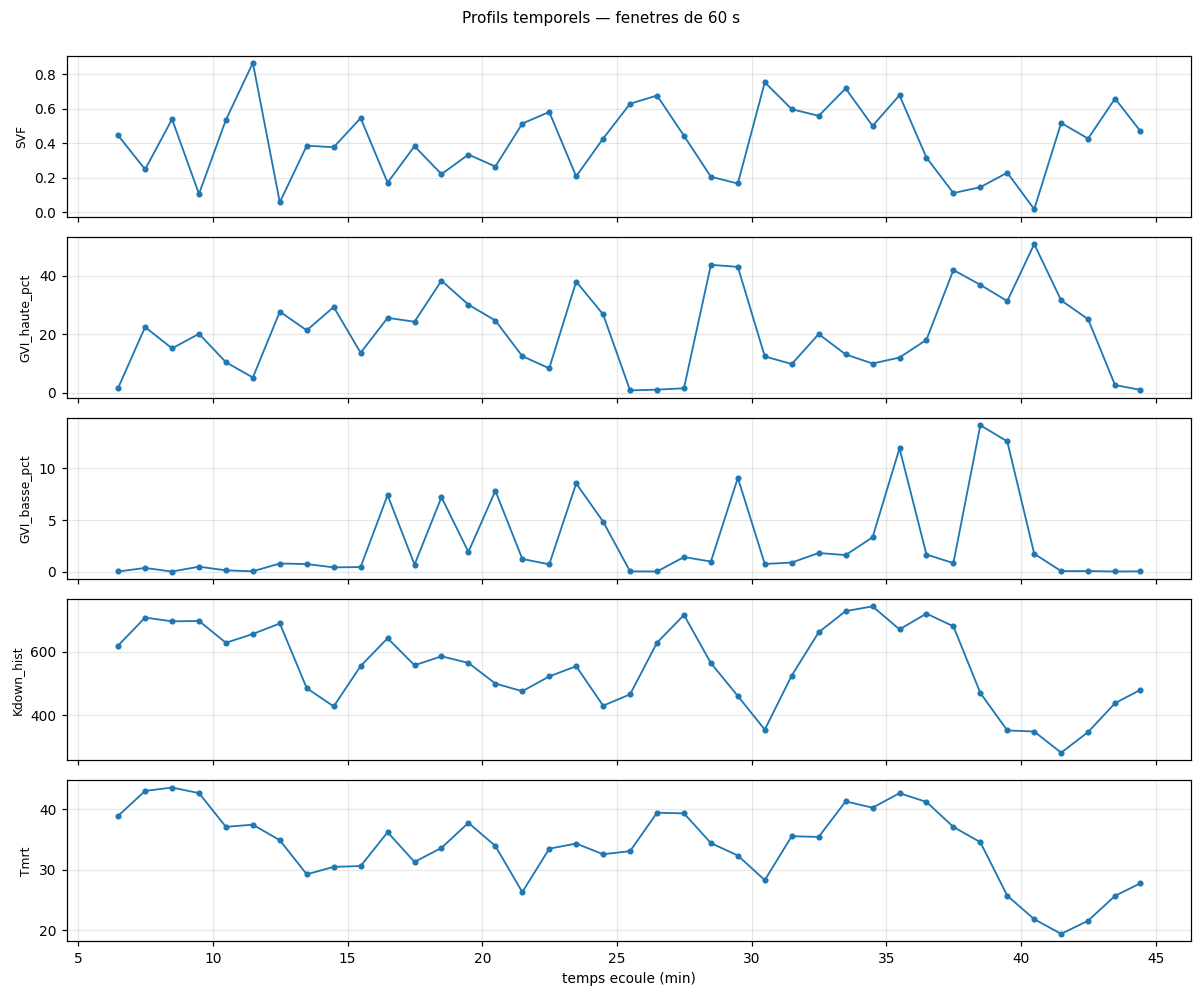

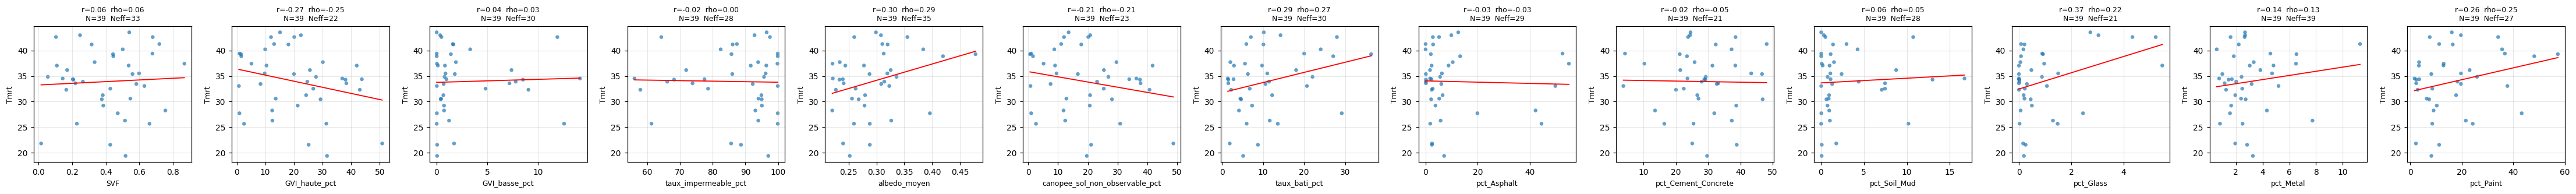

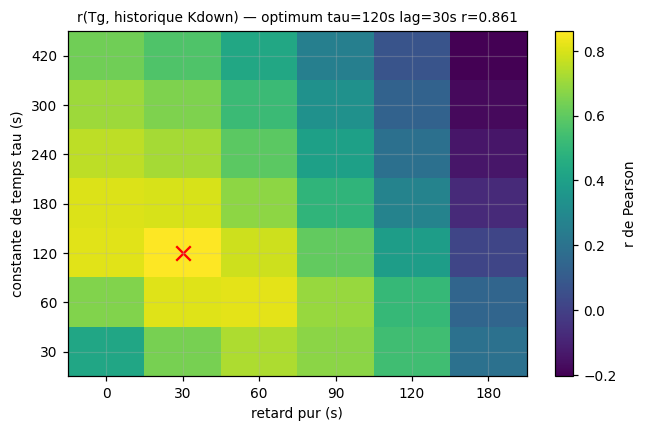

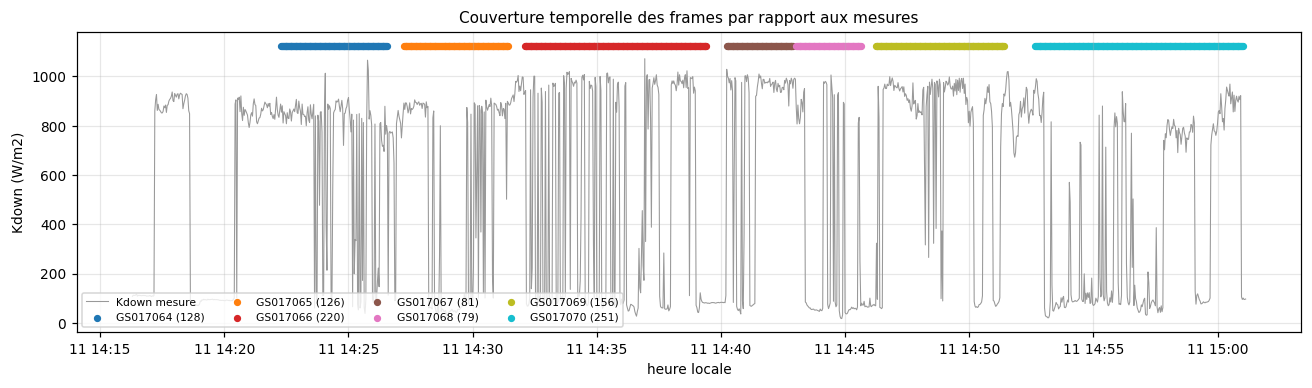

Figures ecrites dans C:\Users\youss\Downloads\coolpath_local\data\outputs\correlation_v2_temporelle_1041\viz


In [14]:
# ---- F1 : profils temporels ----------------------------------------------
a_tracer = [c for c in COLS_IND[:3] + ["Kdown_hist", "Tmrt"] if c in TAB.columns]
fig, axes = plt.subplots(len(a_tracer), 1, figsize=(11, 1.8 * len(a_tracer)), sharex=True)
axes = np.atleast_1d(axes)
for ax, col in zip(axes, a_tracer):
    ax.plot(TAB.t_mid_s / 60, TAB[col], lw=1.2, marker="o", ms=3)
    ax.set_ylabel(col, fontsize=8)
axes[-1].set_xlabel("temps ecoule (min)")
fig.suptitle(f"Profils temporels — fenetres de {FENETRE_REF} s", y=1.0, fontsize=10)
fig.savefig(VIZ_DIR / "F1_profils_temporels.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- F2 : nuages de points ------------------------------------------------
cible_fig = "Tmrt" if TAB.Tmrt.notna().any() else "Kdown_hist"
n = len(COLS_IND)
fig, axes = plt.subplots(1, n, figsize=(3.1 * n, 3.1))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, COLS_IND):
    d = TAB[[col, cible_fig]].dropna()
    ax.scatter(d[col], d[cible_fig], s=18, alpha=0.7, edgecolors="none")
    if len(d) > 3:
        b = np.polyfit(d[col], d[cible_fig], 1)
        xs = np.linspace(d[col].min(), d[col].max(), 50)
        ax.plot(xs, np.polyval(b, xs), "r-", lw=1.2)
        st = correlation_robuste(d[col], d[cible_fig])
        ax.set_title(f"r={st['r']:.2f}  rho={st['rho']:.2f}\n"
                     f"N={st['n']}  Neff={st['n_eff']:.0f}", fontsize=8)
    ax.set_xlabel(col, fontsize=8); ax.set_ylabel(cible_fig, fontsize=8)
fig.savefig(VIZ_DIR / "F2_nuages_points.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- F3 : calibration de l'inertie ---------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(grille.to_numpy(float), aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(range(len(LAGS)), [str(l) for l in LAGS])
ax.set_yticks(range(len(TAUS)), [str(t) for t in TAUS])
ax.set_xlabel("retard pur (s)"); ax.set_ylabel("constante de temps tau (s)")
ax.set_title(f"r(Tg, historique Kdown) — optimum tau={TAU_OPT}s lag={LAG_OPT}s r={r_opt:.3f}",
             fontsize=9)
ax.scatter(LAGS.index(LAG_OPT), TAUS.index(TAU_OPT), marker="x", s=90, c="red")
fig.colorbar(im, ax=ax, label="r de Pearson")
fig.savefig(VIZ_DIR / "F3_inertie_globe.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- F4 : couverture temporelle ------------------------------------------
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(cp.ts, cp.Kdown, lw=0.7, color="0.6", label="Kdown mesure")
couleurs = plt.cm.tab10(np.linspace(0, 1, len(T0_CHAPITRES)))
for (ch, coul) in zip(sorted(T0_CHAPITRES), couleurs):
    g = ind[ind.chapitre == ch]
    if len(g):
        ax.scatter(g.ts, np.full(len(g), cp.Kdown.max() * 1.05), s=14,
                   color=coul, label=f"{ch} ({len(g)})")
ax.set_ylabel("Kdown (W/m2)"); ax.set_xlabel("heure locale")
ax.set_title("Couverture temporelle des frames par rapport aux mesures", fontsize=10)
ax.legend(fontsize=7, ncol=4, loc="lower left")
fig.savefig(VIZ_DIR / "F4_couverture_temporelle.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Figures ecrites dans {VIZ_DIR}")

## 14. Synthese et limites

### Ce que cette version etablit

1. **La synchronisation ne depend plus du GPS** : chaque frame porte son index natif, et
   `T0(chapitre) + idx/fps` donne son horodatage. Verifie coherent sur 6 chapitres sur 7.
2. **L'appariement frame <-> mesure fonctionne** : les 116 frames annotees tombent toutes
   dans la fenetre de mesures et s'apparient a moins de 2 s.
3. **L'inertie du globe est quantifiee** et justifie l'agregation par fenetres plutot que
   par image isolee.
4. **L'autocorrelation est corrigee** et la derive temporelle integree comme regresseur.

### Limites a porter au rapport

| Limite | Portee |
|---|---|
| **N faible (19 a 56 segments)** | limite principale ; aucune conclusion solide a cette taille. Passer aux 1041 frames candidates est le levier prioritaire |
| `D_GLOBE` confirme (0,04 m) mais tres petit -> biais convectif stochastique (Teitelbaum 2020) ; `EPS_GLOBE`, `Z_ANEMO` toujours non confirmes | Tmrt et UTCI absolus a interpreter avec prudence ; les correlations relatives restent valides |
| Coherence GS017064 non resolue | a trancher par `exiftool` ; sans impact si T0 est correct |
| Convection libre (Teitelbaum et al. 2020) | ISO 7726 sous-estime la correction en air calme |
| Profil logarithmique du vent | non valide dans une canopee urbaine ; approximation assumee |
| BFMS -> « Background » sur 93-99 % des surfaces | `albedo_moyen` reflete largement la table contextuelle, pas des detections |
| Indicateurs isotropes | le SVF ne distingue pas un ciel ouvert cote soleil d'un ciel ouvert a l'oppose |
| **Pas de restitution cartographique** | consequence assumee de l'abandon du GPS |
| Un seul parcours | pas de generalisation possible |

### Prochaines etapes, par ordre de priorite

1. **Etendre les indicateurs aux 1041 frames candidates** — inference nb23 -> nb25 -> nb29,
   sans re-annotation. Ce notebook tournera tel quel, avec ~9x plus de segments.
2. **Confirmer les trois constantes du globe** aupres d'Auline Rodler.
3. **Trancher la coherence de GS017064** (`exiftool -Duration -VideoFrameRate`).
4. ~~Verifier le doublon `GVI_haute_pct` / `canopee_sol_non_observable_pct`~~ — **corrige** : retiree des predicteurs de regression (§12).
5. Optionnel : occlusion solaire (position du soleil + masque de ciel) pour lever
   l'isotropie du SVF et passer d'une correlation statistique a une validation physique.